First 5 Rows
   Gender  HoursStudied/Week Tutoring Region  Attendance(%) Parent Education  \
0    Male                5.5       No  Urban           72.7         Tertiary   
1  Female                6.8       No  Urban           62.0          Primary   
2  Female                9.7       No  Rural           95.0        Secondary   
3    Male               13.3      Yes  Rural           52.9              NaN   
4  Female                8.9       No  Urban           50.8              NaN   

   Exam_Score  
0        43.5  
1        51.7  
2        70.1  
3        79.5  
4        52.2  

Dataset Shape
(4000, 7)

Columns
Index(['Gender', 'HoursStudied/Week', 'Tutoring', 'Region', 'Attendance(%)',
       'Parent Education', 'Exam_Score'],
      dtype='object')

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender        

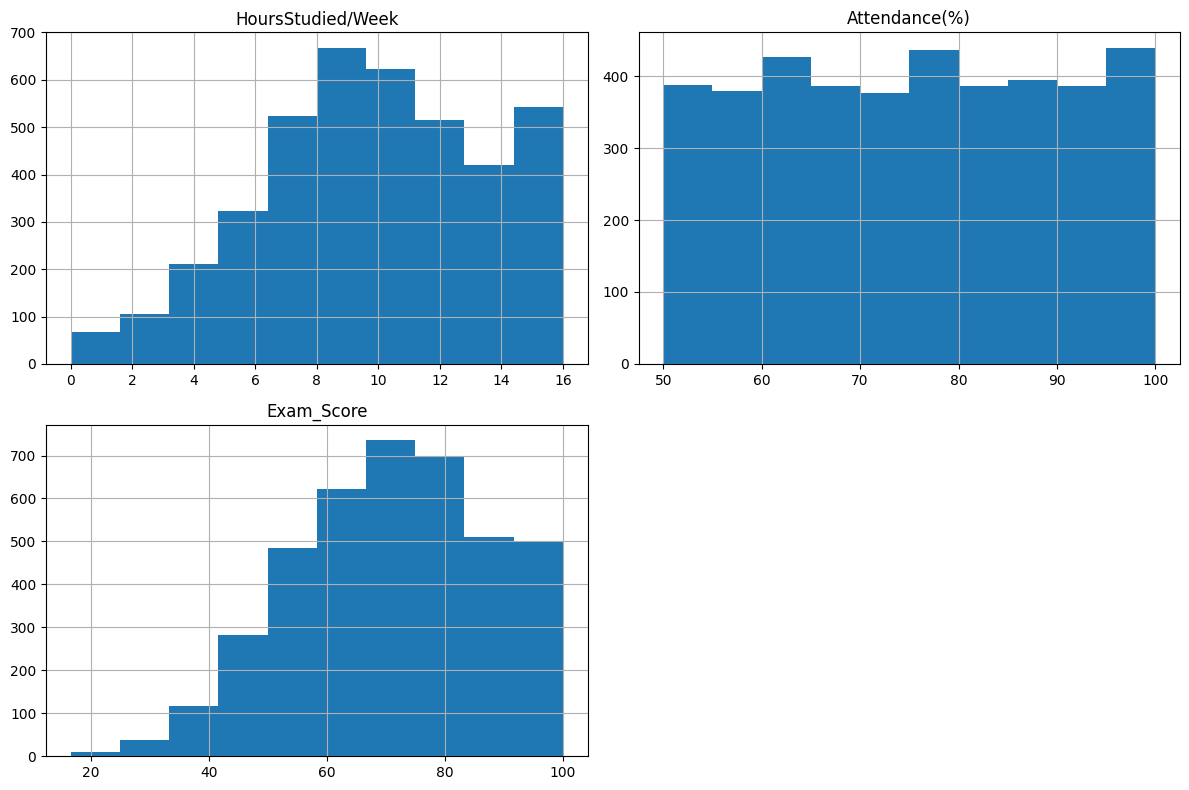

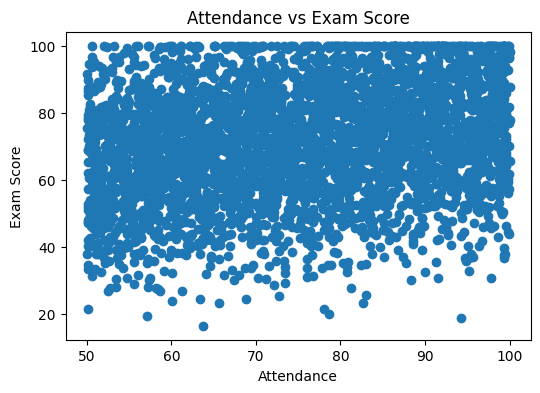

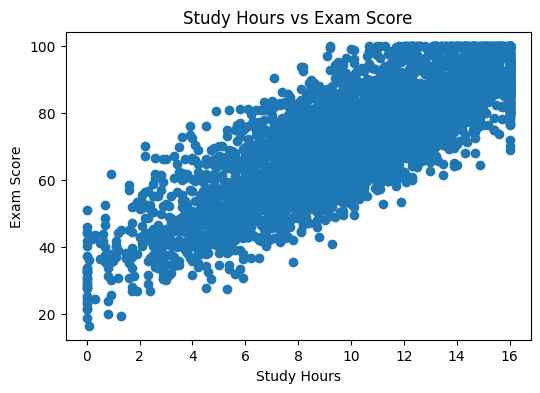

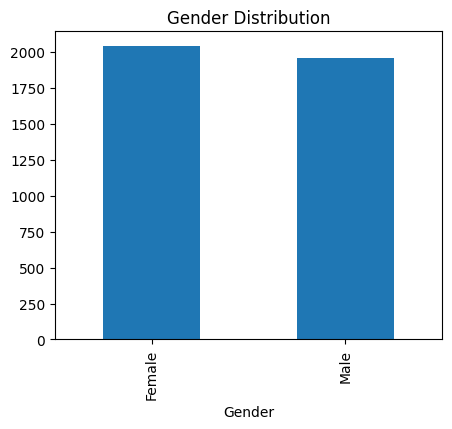

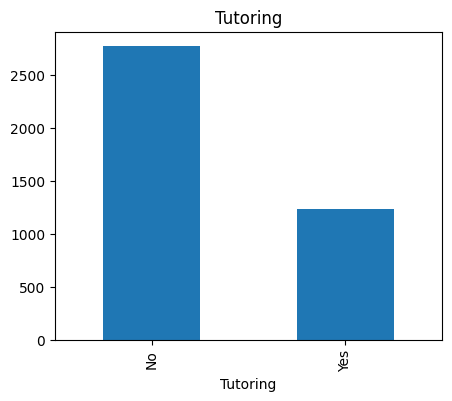

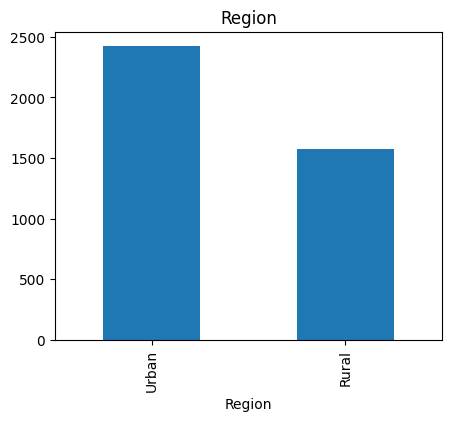

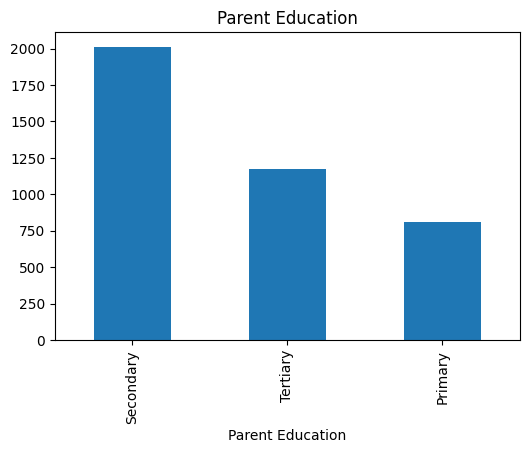


Correlation Matrix
                   HoursStudied/Week  Attendance(%)  Exam_Score
HoursStudied/Week           1.000000       0.003607    0.819812
Attendance(%)               0.003607       1.000000    0.238570
Exam_Score                  0.819812       0.238570    1.000000

Linear Regression
MAE : 3.987364085436523
RMSE: 5.027301614409776
R2 Score: 0.9155656411478306

Decision Tree
MAE : 5.8768125
RMSE: 7.602817939751023
R2 Score: 0.8068927815232441

Random Forest
MAE : 4.3320471666666664
RMSE: 5.513902857044287
R2 Score: 0.8984295099755479

Gradient Boosting
MAE : 4.070396704379798
RMSE: 5.1509571309406805
R2 Score: 0.9113609286124934

Model Comparison
               Model       MAE      RMSE  R2 Score
0  Linear Regression  3.987364  5.027302  0.915566
1      Decision Tree  5.876812  7.602818  0.806893
2      Random Forest  4.332047  5.513903  0.898430
3  Gradient Boosting  4.070397  5.150957  0.911361

Best Model Saved Successfully

Predicted Exam Score
105.11701490098712

Project 

In [3]:
# ==========================================
# Student Academic Performance Prediction
# Major Project - Complete Code
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("SAP-4000.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

# ==========================================
# Missing Values
# ==========================================

print("\nMissing Values")
print(df.isnull().sum())

# Fill Missing Values

if "Parent Education" in df.columns:
    df["Parent Education"] = df["Parent Education"].fillna(df["Parent Education"].mode()[0])

# Remove duplicates
df = df.drop_duplicates()

print("\nShape After Removing Duplicates")
print(df.shape)

# ==========================================
# Exploratory Data Analysis
# ==========================================

# Histogram

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

# Attendance vs Score

plt.figure(figsize=(6,4))
plt.scatter(df["Attendance(%)"],df["Exam_Score"])
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")
plt.show()

# Study Hours vs Score

plt.figure(figsize=(6,4))
plt.scatter(df["HoursStudied/Week"],df["Exam_Score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.show()

# Gender Distribution

plt.figure(figsize=(5,4))
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

# Tutoring Distribution

plt.figure(figsize=(5,4))
df["Tutoring"].value_counts().plot(kind="bar")
plt.title("Tutoring")
plt.show()

# Region Distribution

plt.figure(figsize=(5,4))
df["Region"].value_counts().plot(kind="bar")
plt.title("Region")
plt.show()

# Parent Education Distribution

plt.figure(figsize=(6,4))
df["Parent Education"].value_counts().plot(kind="bar")
plt.title("Parent Education")
plt.show()

# Correlation Matrix

print("\nCorrelation Matrix")
print(df.corr(numeric_only=True))

# ==========================================
# Feature Selection
# ==========================================

X = df.drop("Exam_Score", axis=1)

y = df["Exam_Score"]

categorical_features = [
    "Gender",
    "Tutoring",
    "Region",
    "Parent Education"
]

# ==========================================
# Data Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================
# Preprocessing
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

# ==========================================
# Models
# ==========================================

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

best_model = None
best_r2 = -999

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

    print("\n===============================")
    print(name)
    print("===============================")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

    if r2 > best_r2:
        best_r2 = r2
        best_model = pipeline

# ==========================================
# Model Comparison
# ==========================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

print("\nModel Comparison")
print(results_df)

# ==========================================
# Save Best Model
# ==========================================

joblib.dump(best_model, "student_performance_model.pkl")

print("\nBest Model Saved Successfully")

# ==========================================
# Sample Prediction
# ==========================================

sample = pd.DataFrame({

    "Gender":["Male"],

    "HoursStudied/Week":[15],

    "Tutoring":["Yes"],

    "Region":["Urban"],

    "Attendance(%)":[92],

    "Parent Education":["Graduate"]

})

prediction = best_model.predict(sample)

print("\nPredicted Exam Score")

print(prediction[0])

# ==========================================
# Feature Importance
# (Only for Tree Models)
# ==========================================

model_name = results_df.sort_values("R2 Score", ascending=False).iloc[0]["Model"]

if model_name != "Linear Regression":

    estimator = best_model.named_steps["model"]

    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

    importance = estimator.feature_importances_

    feature_df = pd.DataFrame({
        "Feature":feature_names,
        "Importance":importance
    })

    feature_df = feature_df.sort_values("Importance",ascending=False)

    print("\nFeature Importance")
    print(feature_df)

    plt.figure(figsize=(10,6))

    plt.barh(feature_df["Feature"],feature_df["Importance"])

    plt.title("Feature Importance")

    plt.gca().invert_yaxis()

    plt.show()

print("\nProject Completed Successfully.")

In [4]:
print("\n===============================")
print("Train and Test Accuracy")
print("===============================")

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)

    print(f"{name}")
    print("Train R2 :", train_score)
    print("Test R2  :", test_score)
    print()


Train and Test Accuracy
Linear Regression
Train R2 : 0.9060663088251737
Test R2  : 0.9155656411478306

Decision Tree
Train R2 : 0.9996657688150071
Test R2  : 0.8068927815232441

Random Forest
Train R2 : 0.9846342528409131
Test R2  : 0.8984295099755479

Gradient Boosting
Train R2 : 0.9202351446135111
Test R2  : 0.9113609286124934



In [5]:
from sklearn.model_selection import cross_val_score

print("\n===============================")
print("Cross Validation")
print("===============================")

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    print(name)
    print("Scores :", scores)
    print("Average :", scores.mean())
    print()


Cross Validation
Linear Regression
Scores : [0.91743204 0.90316972 0.90028257 0.91143532 0.90402344]
Average : 0.907268616496669

Decision Tree
Scores : [0.81378212 0.81293463 0.79213539 0.78526453 0.8016534 ]
Average : 0.8011540140743104

Random Forest
Scores : [0.90375295 0.89353239 0.88283285 0.8919428  0.88533841]
Average : 0.8914798797486275

Gradient Boosting
Scores : [0.91729182 0.90505698 0.89737858 0.90912035 0.89902487]
Average : 0.905574519504663



In [6]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

params = {
    "model__n_estimators":[100,200],
    "model__max_depth":[5,10,None]
}

grid = GridSearchCV(
    pipeline,
    params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train,y_train)

print("Best Parameters")
print(grid.best_params_)

print("Best Score")
print(grid.best_score_)

Best Parameters
{'model__max_depth': 10, 'model__n_estimators': 200}
Best Score
0.8946548904151257


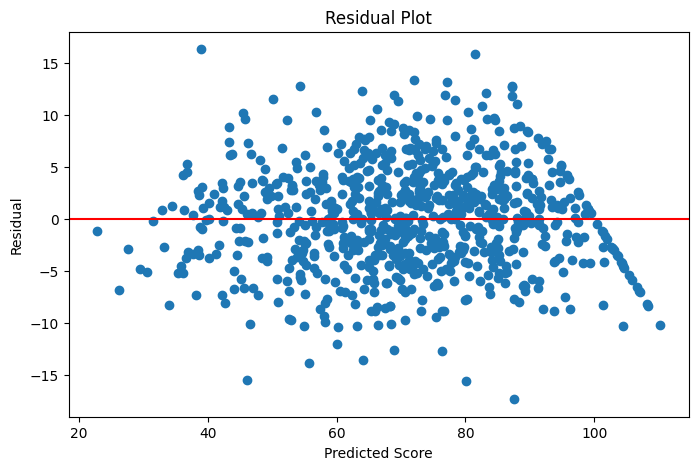

In [7]:
best_predictions = best_model.predict(X_test)

residuals = y_test - best_predictions

plt.figure(figsize=(8,5))

plt.scatter(best_predictions,residuals)

plt.axhline(y=0,color='red')

plt.xlabel("Predicted Score")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

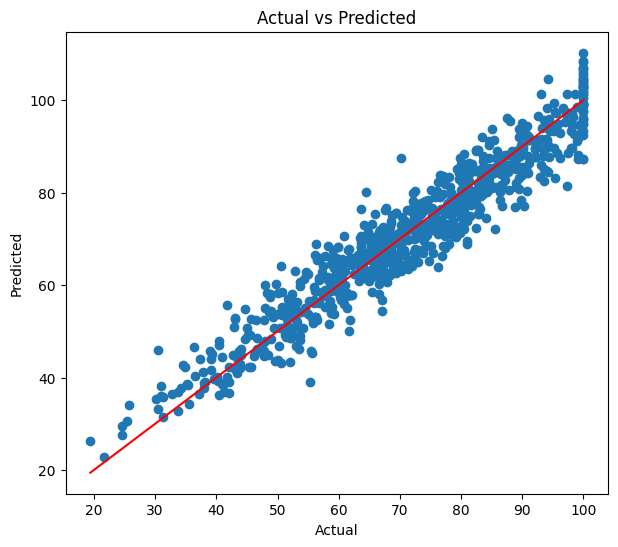

In [8]:
plt.figure(figsize=(7,6))

plt.scatter(y_test,best_predictions)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color='red'
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

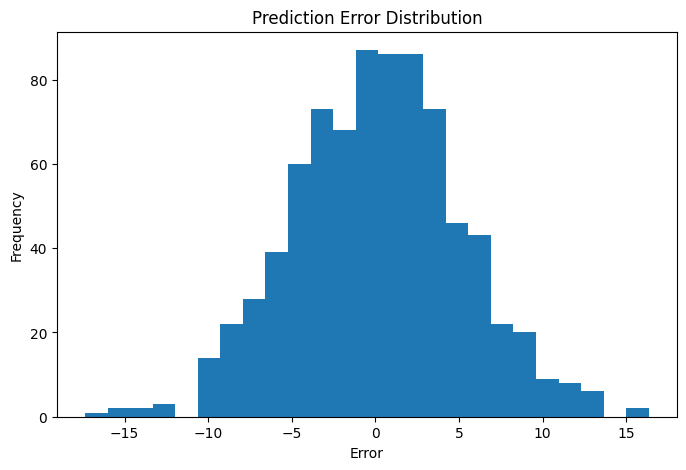

In [9]:
errors = y_test - best_predictions

plt.figure(figsize=(8,5))

plt.hist(errors,bins=25)

plt.title("Prediction Error Distribution")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()

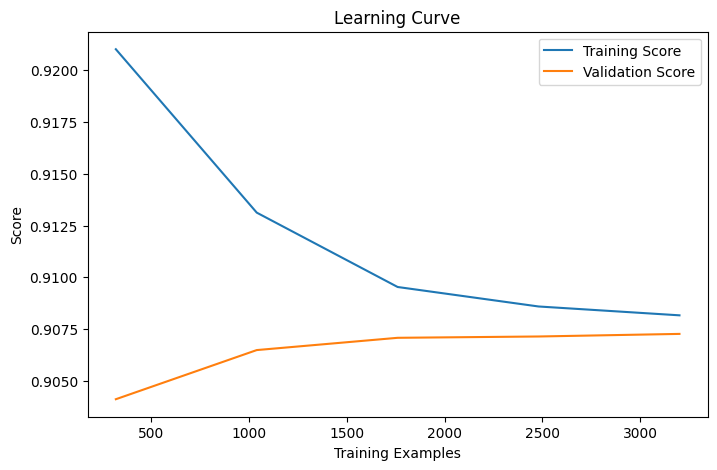

In [10]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5
)

train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes,train_mean,label="Training Score")

plt.plot(train_sizes,test_mean,label="Validation Score")

plt.legend()

plt.xlabel("Training Examples")

plt.ylabel("Score")

plt.title("Learning Curve")

plt.show()

In [11]:
if hasattr(best_model.named_steps["model"],"feature_importances_"):

    names = best_model.named_steps["preprocessor"].get_feature_names_out()

    importance = best_model.named_steps["model"].feature_importances_

    feature_importance = pd.DataFrame({
        "Feature":names,
        "Importance":importance
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print(feature_importance)

    plt.figure(figsize=(10,6))

    plt.barh(
        feature_importance["Feature"],
        feature_importance["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.title("Feature Importance")

    plt.show()

In [12]:
results_df.to_csv("Model_Comparison.csv",index=False)

print("Model comparison saved.")

Model comparison saved.


In [13]:
prediction_df = pd.DataFrame({
    "Actual":y_test,
    "Predicted":best_predictions
})

prediction_df.to_csv("Predictions.csv",index=False)

print("Predictions saved.")

Predictions saved.


In [14]:
prediction_df = pd.DataFrame({
    "Actual":y_test,
    "Predicted":best_predictions
})

prediction_df.to_csv("Predictions.csv",index=False)

print("Predictions saved.")


Predictions saved.


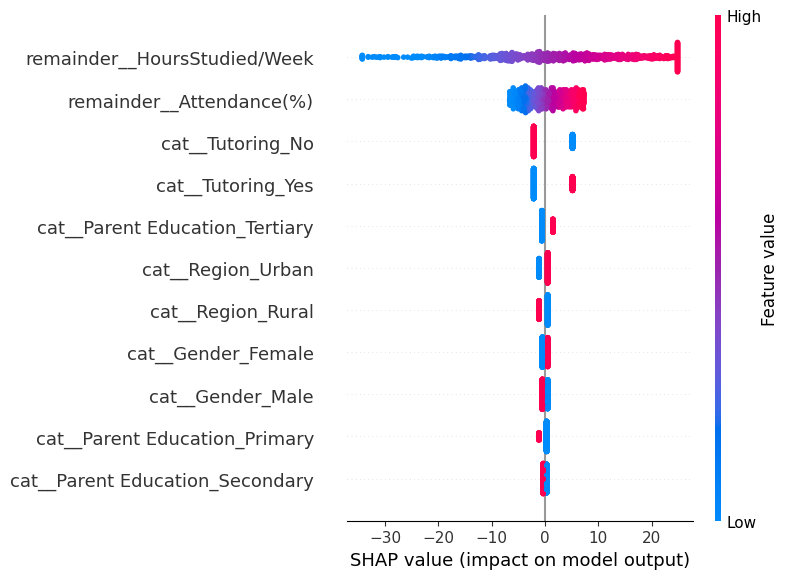

In [18]:

import shap

# Transform the data
X_train_transformed = best_model.named_steps["preprocessor"].transform(X_train)
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)

# Use LinearExplainer
explainer = shap.LinearExplainer(
    best_model.named_steps["model"],
    X_train_transformed
)

shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=best_model.named_steps["preprocessor"].get_feature_names_out()
)